In [7]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
titanic = sns.load_dataset("titanic")

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
titanic.head()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [11]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
features = ["pclass","sex","fare","embarked","age"]
target=["survived"]

In [14]:
#Missing data
from sklearn.impute import SimpleImputer

imp_median= SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [15]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [16]:
# encode

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])



In [17]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [18]:
x= titanic[features]
y= titanic[target]

In [19]:
x.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42)



In [21]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


# Decision Tree Model - no pruning

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
    
print("cm:", confusion_matrix(y_test, y_pred))

print("classification report:", classification_report(y_test, y_pred))

Accuracy: 0.7649253731343284
cm: [[124  33]
 [ 30  81]]
classification report:               precision    recall  f1-score   support

           0       0.81      0.79      0.80       157
           1       0.71      0.73      0.72       111

    accuracy                           0.76       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.76      0.77       268



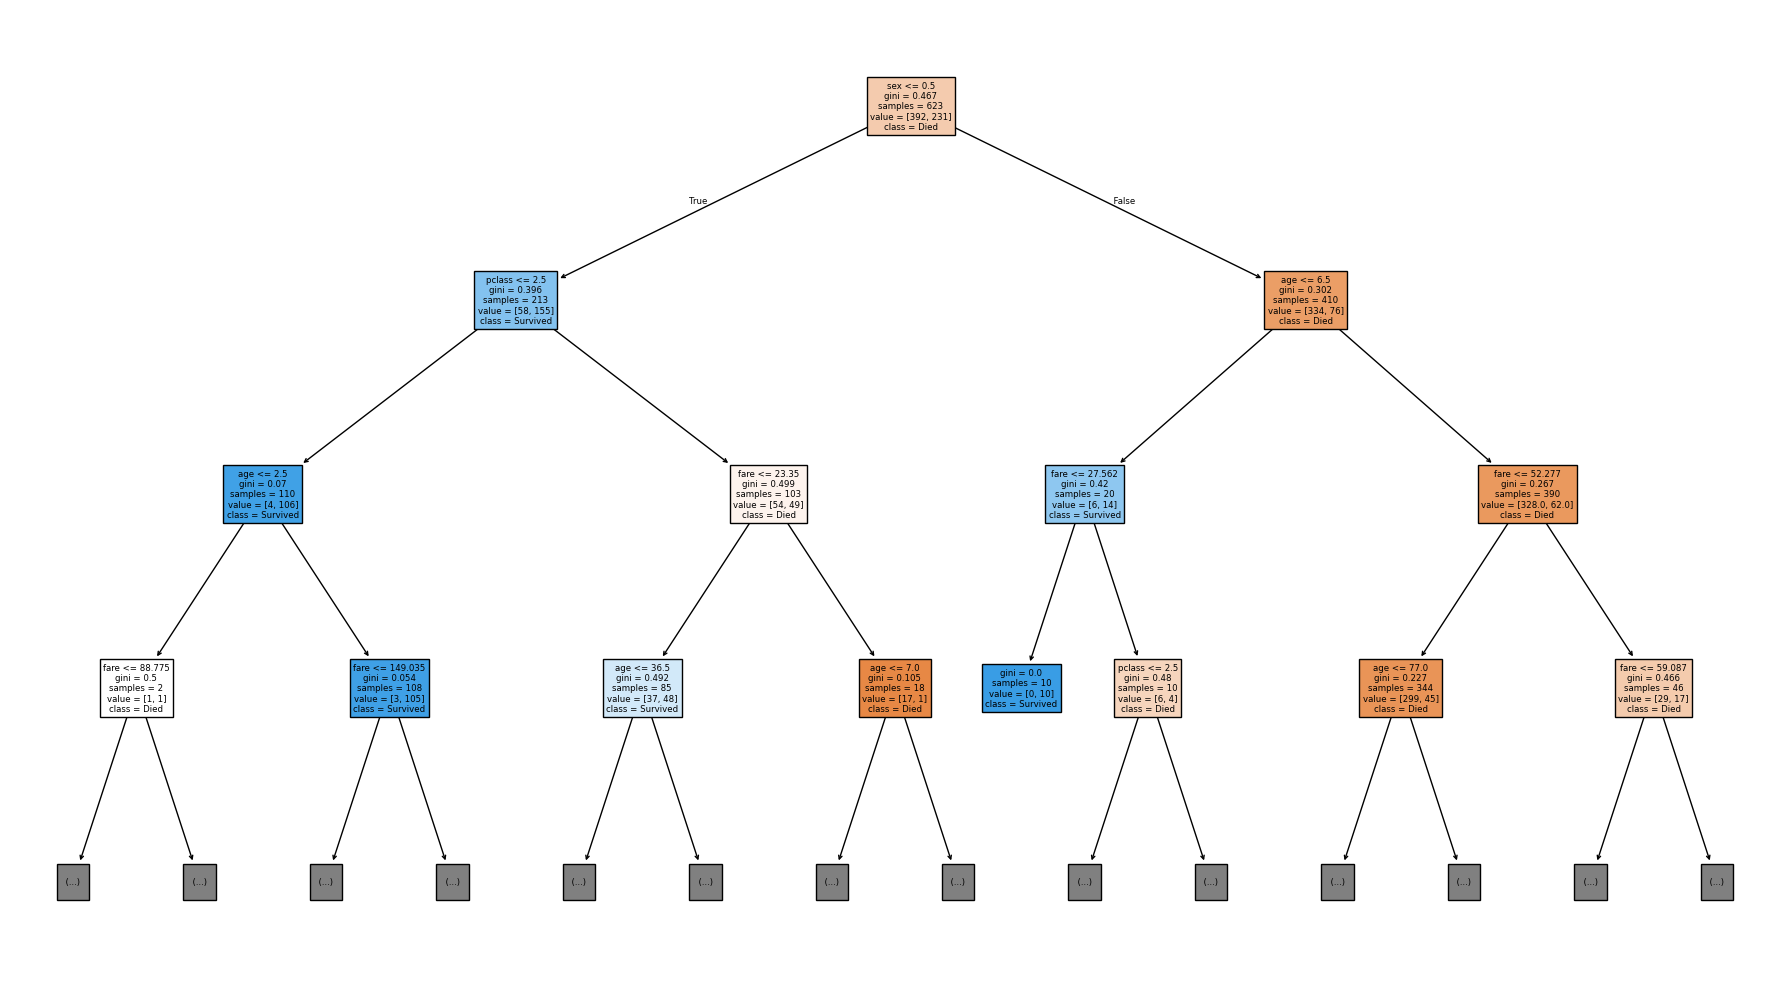

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=3
)

plt.tight_layout()
plt.show()

# Decision Tree with pre-pruning

for depth = 2 , accuraccy = 0.7723880597014925


<Figure size 640x480 with 0 Axes>

for depth = 3 , accuraccy = 0.8059701492537313


<Figure size 640x480 with 0 Axes>

for depth = 4 , accuraccy = 0.8246268656716418


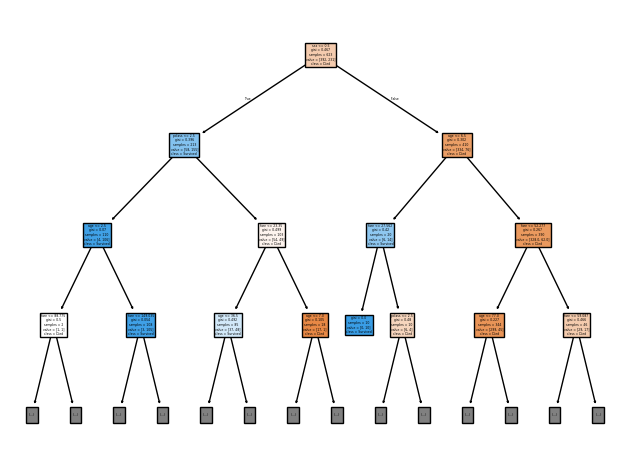

for depth = 5 , accuraccy = 0.7985074626865671


<Figure size 640x480 with 0 Axes>

for depth = 6 , accuraccy = 0.7873134328358209


<Figure size 640x480 with 0 Axes>

for depth = 7 , accuraccy = 0.7798507462686567


<Figure size 640x480 with 0 Axes>

for depth = 8 , accuraccy = 0.8022388059701493


<Figure size 640x480 with 0 Axes>

for depth = 9 , accuraccy = 0.7649253731343284


<Figure size 640x480 with 0 Axes>

for depth = 10 , accuraccy = 0.7910447761194029


<Figure size 640x480 with 0 Axes>

In [72]:
max_depth= [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc= model.score(X_test, y_test)
    print(f"for depth = {depth} , accuraccy = {acc}")

    if depth==4:
        plot_tree(
        model,
        feature_names=x.columns,
        class_names=["Died","Survived"],
        filled=True,
        max_depth=3
   )

    plt.tight_layout()
    plt.show()

for sample split= 5 , accuraccy = 0.8246268656716418


<Figure size 640x480 with 0 Axes>

for sample split= 10 , accuraccy = 0.8246268656716418


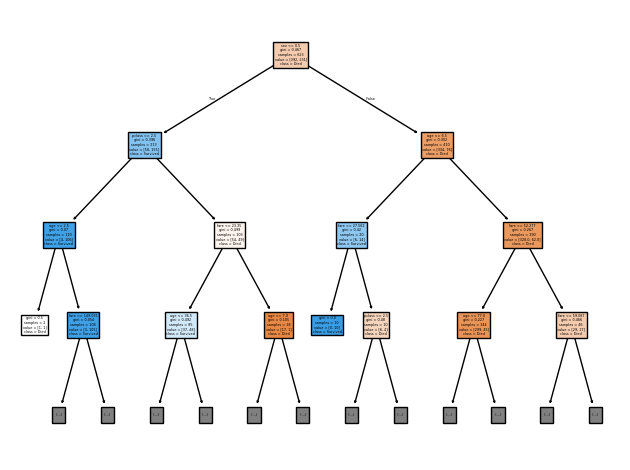

for sample split= 15 , accuraccy = 0.8171641791044776


<Figure size 640x480 with 0 Axes>

for sample split= 20 , accuraccy = 0.8171641791044776


<Figure size 640x480 with 0 Axes>

for sample split= 25 , accuraccy = 0.8208955223880597


<Figure size 640x480 with 0 Axes>

for sample split= 30 , accuraccy = 0.8208955223880597


<Figure size 640x480 with 0 Axes>

In [74]:
min_samples_splits= [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc= model.score(X_test, y_test)
    print(f"for sample split= {split} , accuraccy = {acc}")


    if split==10:
        plot_tree(
        model,
        feature_names=x.columns,
        class_names=["Died","Survived"],
        filled=True,
        max_depth=3
   )

    plt.tight_layout()
    plt.show()

# Decision Tree with Post-pruning

In [75]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [84]:
# train our model for all alphas 

tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)


    tree.append((model, acc))

In [86]:
best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [87]:
best_alpha

0.585820895522388

In [88]:
best_acc

0.8208955223880597

In [92]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


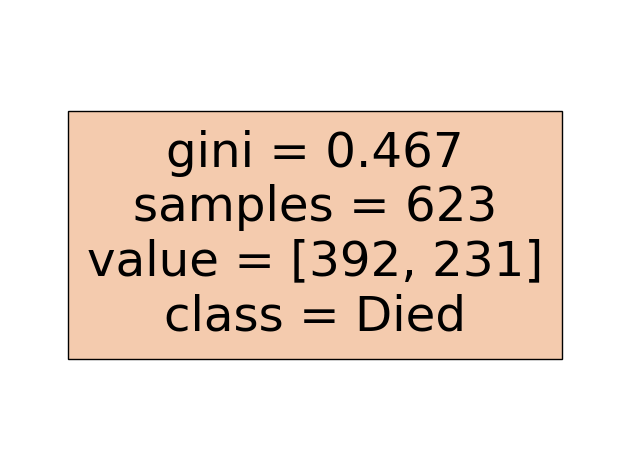

In [95]:
plot_tree(
        best_model,
        feature_names=x.columns,
        class_names=["Died","Survived"],
        filled=True,
   )

plt.tight_layout()
plt.show()